# **`NumPy` para economistas**

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/franperezec/propedeutico-flacso/blob/main/clases/matrices/numpy_para_economistas.ipynb)


# Arreglos y matrices con NumPy 1

**Propedéutico — Maestría en Economía · FLACSO Ecuador**

**Profesor:** Francisco Pérez M.

**Correo:** francisco.perezxxi@gmail.com

---

Información sobre la librería de `Python` para trabajar con `Numpy` y `Google Sheets`:
[algebra-lineal.sheets](https://pypi.org/project/algebra-lineal-sheets/)

# **A. Introducción a `Numpy`**

## **1. Repensando la Dimensionalidad en `NumPy`**

### Un Nuevo Modelo Mental para Entender los Arrays

#### ¿Cómo pensamos realmente sobre las dimensiones?

Cuando trabajamos con arrays en NumPy, es fundamental desarrollar un modelo mental preciso sobre cómo funcionan las dimensiones. Muchas veces aplicamos conceptos matemáticos tradicionales que pueden confundirnos.

#### La Regla de Oro: "El Último y el Penúltimo"

**Concepto clave**: En lugar de pensar solo en "fila, columna" para matrices 2D, es mejor pensar así:
- El **último** índice corresponde a las **columnas**
- El **penúltimo** índice corresponde a las **filas**

Este modelo mental es útil porque **se generaliza a cualquier número de dimensiones**:

```python
import numpy as np

# Array 2D: shape (3, 4)
arr_2d = np.array([[1, 2, 3, 4],
                   [5, 6, 7, 8],
                   [9, 10, 11, 12]])
# Último índice (columnas): 4 elementos
# Penúltimo índice (filas): 3 elementos

# Array 3D: shape (2, 3, 4)
arr_3d = np.zeros((2, 3, 4))
# Último índice: 4 elementos
# Penúltimo índice: 3 elementos  
# Antepenúltimo índice: 2 elementos
```

#### Cuidado con la Terminología

Aunque es común escuchar estos términos:
- Array 0-D → "escalar"
- Array 1-D → "vector"
- Array 2-D → "matriz"
- Array N-D → "tensor"

**¡Evita usar estos términos matemáticos al referirte a arrays de NumPy!**

**¿Por qué?** Porque los objetos matemáticos se comportan diferente a los arrays:
- La multiplicación de matrices (matemática) ≠ multiplicación de arrays (NumPy)
- Un "tensor" en matemáticas ≠ array N-D en NumPy
- Además, otros frameworks (como PyTorch) usan "tensor" para sus propias estructuras

#### Ejercicio Mental

Cuando veas un array con shape `(5, 3, 8, 2)`, piensa:
- **Último**: 2 elementos
- **Penúltimo**: 8 elementos
- **Antepenúltimo**: 3 elementos
- **Primero**: 5 elementos

Este array tiene 4 dimensiones, y cada una tiene un significado específico según su posición.

#### En resumen

Desarrollar este modelo mental te ayudará a:
1. Entender mejor las operaciones de NumPy
2. Evitar confusiones con conceptos matemáticos
3. Trabajar con arrays de cualquier dimensionalidad
4. Escribir código más claro y predecible

**Recuerda**: NumPy trabaja con arrays, no con objetos matemáticos tradicionales. ¡Piensa en arrays!

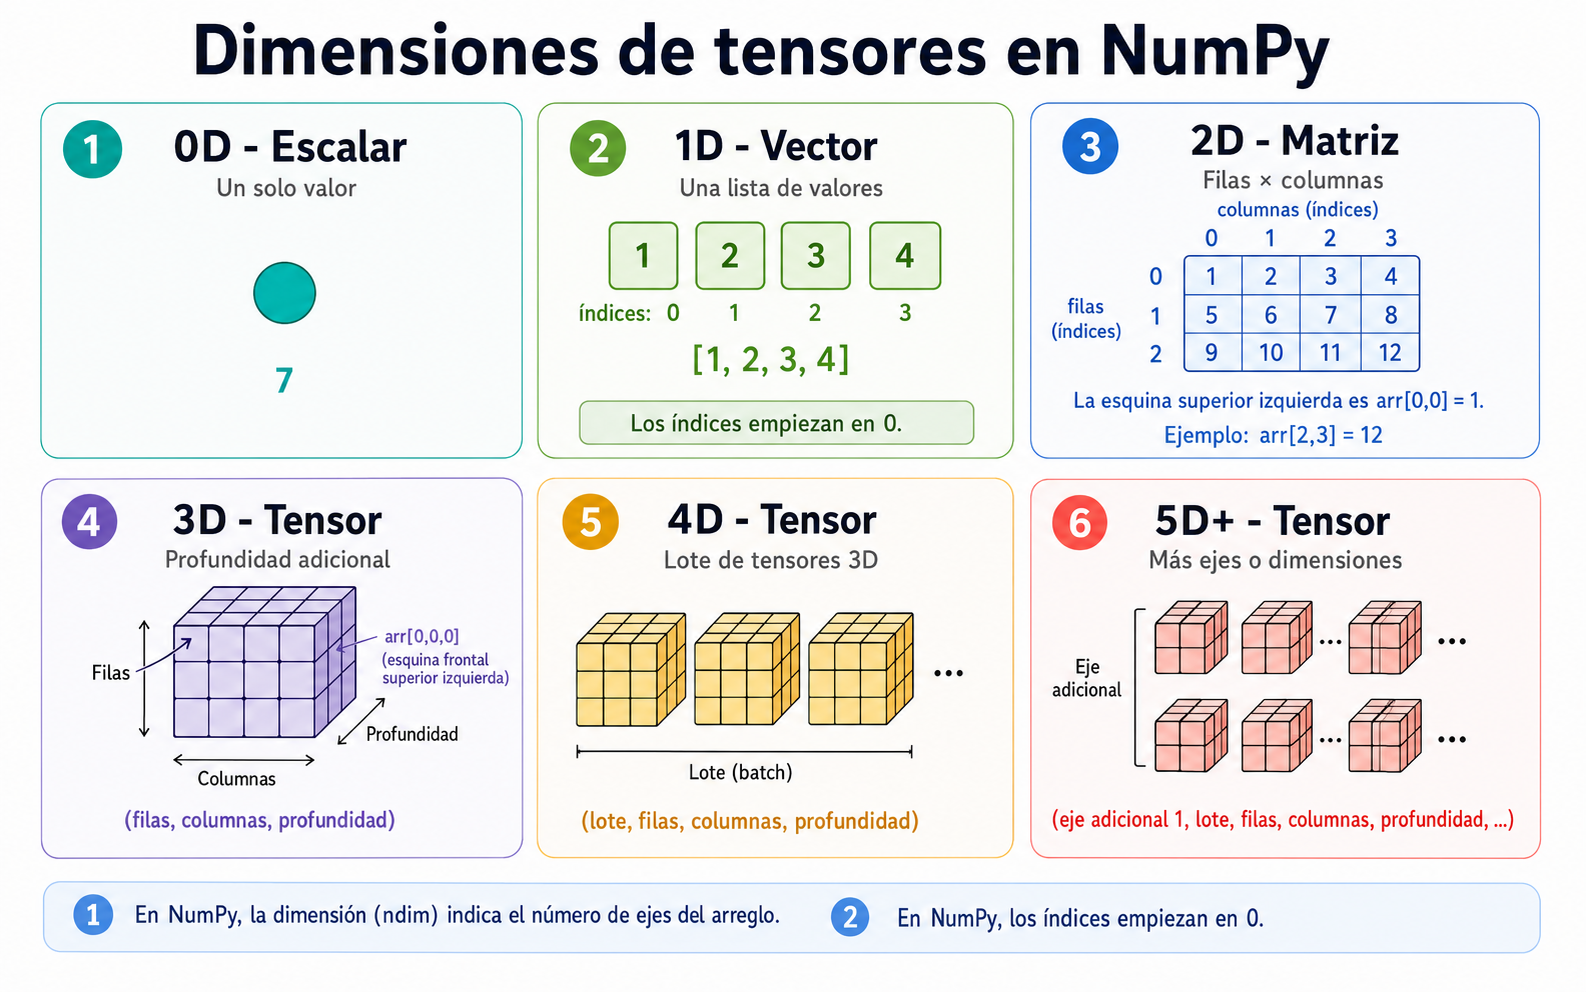

In [1]:
import numpy as np

# 0D array (Escalar)
scalar = np.array(5)
print("Array 0D (Escalar):")
print(scalar)
print("Dimension:", scalar.shape)
print("Número de dimensiones:", scalar.ndim)
print("-" * 20)

# 1D array (Vector)
vector = np.array([1, 2, 3, 4])
print("Array 1D (Vector):")
print(vector)
print("Dimension:", vector.shape)
print("Número de dimensiones:", vector.ndim)
print("-" * 20)

# 2D array (Matriz)
matrix = np.array([[1, 2, 3],
                   [4, 5, 6]])
print("Array 2D (Matriz):")
print(matrix)
print("Dimension:", matrix.shape)
print("Número de dimensiones:", matrix.ndim)
print("-" * 20)

# 3D array (Tensor)
tensor_3d = np.array([[[1, 2], [3, 4]],
                      [[5, 6], [7, 8]]])
print("Array 3D (Tensor):")
print(tensor_3d)
print("Dimension:", tensor_3d.shape)
print("Número de dimensiones:", tensor_3d.ndim)
print("-" * 20)

Array 0D (Escalar):
5
Dimension: ()
Número de dimensiones: 0
--------------------
Array 1D (Vector):
[1 2 3 4]
Dimension: (4,)
Número de dimensiones: 1
--------------------
Array 2D (Matriz):
[[1 2 3]
 [4 5 6]]
Dimension: (2, 3)
Número de dimensiones: 2
--------------------
Array 3D (Tensor):
[[[1 2]
  [3 4]]

 [[5 6]
  [7 8]]]
Dimension: (2, 2, 2)
Número de dimensiones: 3
--------------------


### **1.1 Redimensionar arreglos**

In [2]:
# Crear una matriz 2x4
matrix_2x4 = np.array([[1, 2, 3, 4],
                       [5, 6, 7, 8]])
print("Matriz 2x4:")
print(matrix_2x4)
print("Dimension:", matrix_2x4.shape)
print("-" * 20)

# Reshape a un tensor 2x2x2
tensor_2x2x2 = matrix_2x4.reshape((2, 2, 2))
print("Tensor 2x2x2 (después de reshape):")
print(tensor_2x2x2)
print("Dimension:", tensor_2x2x2.shape)

# Reshape del tenson 2x2x2 a vector 8x1
vector_8x1 = tensor_2x2x2.reshape((8, 1))
print("Vector 8x1 (después de reshape):")
print(vector_8x1)
print("Dimension:", vector_8x1.shape)


Matriz 2x4:
[[1 2 3 4]
 [5 6 7 8]]
Dimension: (2, 4)
--------------------
Tensor 2x2x2 (después de reshape):
[[[1 2]
  [3 4]]

 [[5 6]
  [7 8]]]
Dimension: (2, 2, 2)
Vector 8x1 (después de reshape):
[[1]
 [2]
 [3]
 [4]
 [5]
 [6]
 [7]
 [8]]
Dimension: (8, 1)


## **2. Atributos de un arreglo**

In [3]:
# Array 3D para ver cómo cambian los atributos
c = np.zeros((2, 3, 4))  # Crea un array de 3D (2 matrices, 3 filas, 4 columnas) lleno de ceros. Empieza de la última dimensión.

print("Matriz 3D de ceros:")  # Imprime un título para la salida en la consola.
print(f"c.shape = {c.shape}")   # Imprime la forma del array: (2, 3, 4).
print(f"c.ndim = {c.ndim}")      # Imprime el número de dimensiones del array: 3.
print(f"c.size = {c.size}")      # Imprime el número total de elementos: 2 * 3 * 4 = 24.
print(f"c.dtype = {c.dtype}")   # Imprime el tipo de dato de los elementos (por defecto es float64).
print()                         # Imprime una línea en blanco
print(c)

#d = c.reshape((2, 12))
#print(d)

Matriz 3D de ceros:
c.shape = (2, 3, 4)
c.ndim = 3
c.size = 24
c.dtype = float64

[[[0. 0. 0. 0.]
  [0. 0. 0. 0.]
  [0. 0. 0. 0.]]

 [[0. 0. 0. 0.]
  [0. 0. 0. 0.]
  [0. 0. 0. 0.]]]


## **3. Creación de matrices**

In [4]:
# ----- Básicas

# Crea un array (o vector) de 2 elementos, todos con valor 0.
# El tipo de dato por defecto es de punto flotante (float64).
zeros_array = np.zeros(2)
print(f"Array de ceros: {zeros_array}")

# Crea una matriz de 2x3 (2 filas, 3 columnas) llena de unos.
ones_matrix = np.ones((2, 3))
print(f"\nMatriz de unos:\n{ones_matrix}")

# Crea una matriz vacía de 2x2. Sus valores iniciales son aleatorios
# y dependen de lo que haya en ese momento en la memoria. Es más rápido
# que np.zeros si vas a llenar todos los elementos inmediatamente.
empty_matrix = np.empty((2, 2))
print(f"\nMatriz vacía (valores pueden variar):\n{empty_matrix}")


# --- Creación de matrices con rangos ---

# Crea un array con un rango de números desde 0 hasta 3 (el 4 no se incluye).
range_array = np.arange(4)
print(f"\nArray con rango simple: {range_array}")

# Crea un array con un rango, especificando inicio (2), fin (9, no incluido) y paso (2).
stepped_range_array = np.arange(2, 9, 2)
print(f"\nArray con rango y paso: {stepped_range_array}")

# Crea un array de 5 números espaciados de manera uniforme entre 0 y 10 (ambos incluidos).
# Es muy útil para generar coordenadas o muestreos.
linspace_array = np.linspace(0, 10, num=17)
print(f"\nArray con espaciado lineal: {linspace_array}")


# --- Especificando el tipo de dato (dtype) ---

# Crea un array de unos, pero especifica que los elementos deben ser enteros de 64 bits.
# Esto ahorra memoria si no necesitas decimales.
int_ones_array = np.ones(2, dtype=np.int64)
print(f"\nArray de unos con tipo de dato entero: {int_ones_array}")
print(f"Tipo de dato: {int_ones_array.dtype}")


# --- Creación de matrices especiales: Matriz Identidad ---

# Crea una matriz identidad de 3x3.
# La matriz identidad tiene unos en la diagonal principal y ceros en el resto.
# np.eye() es una forma común de crearla.
identity_matrix = np.eye(3)
print(f"\nMatriz identidad 3x3:\n{identity_matrix}")

# También se puede crear una matriz identidad especificando el tipo de dato.
int_identity_matrix = np.eye(4, dtype=int) # Matriz identidad 4x4 de enteros
print(f"\nMatriz identidad 4x4 con enteros:\n{int_identity_matrix}")

Array de ceros: [0. 0.]

Matriz de unos:
[[1. 1. 1.]
 [1. 1. 1.]]

Matriz vacía (valores pueden variar):
[[0.00000000e+000 9.27159941e-312]
 [9.27159940e-312 9.27159941e-312]]

Array con rango simple: [0 1 2 3]

Array con rango y paso: [2 4 6 8]

Array con espaciado lineal: [ 0.     0.625  1.25   1.875  2.5    3.125  3.75   4.375  5.     5.625
  6.25   6.875  7.5    8.125  8.75   9.375 10.   ]

Array de unos con tipo de dato entero: [1 1]
Tipo de dato: int64

Matriz identidad 3x3:
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]

Matriz identidad 4x4 con enteros:
[[1 0 0 0]
 [0 1 0 0]
 [0 0 1 0]
 [0 0 0 1]]


## **4. Indexación y Segmentación Básica**

### **4.1 Similar a las listas de Python**

In [5]:
# Crear un array de 1D para los ejemplos
data = np.array([10, 20, 30, 40, 50])

# Acceder a un elemento por su índice (el segundo elemento)
print(f"Elemento en el índice 1: {data[-1]}")

# Obtener un segmento (slice) desde el inicio hasta el índice 2 (no incluido)
print(f"Segmento data[0:2]: {data[0:2]}")

# Obtener un segmento desde el índice 2 hasta el final
print(f"Segmento data[2:]: {data[2:]}")

# Obtener los últimos dos elementos del array
print(f"Últimos 2 elementos data[-2:]: {data[-2:]}")

Elemento en el índice 1: 50
Segmento data[0:2]: [10 20]
Segmento data[2:]: [30 40 50]
Últimos 2 elementos data[-2:]: [40 50]


### **4.2 Indexación Booleana (filtrado por condiciones)**

In [6]:
# Crear una matriz 2D para los ejemplos
a = np.array([[1, 2, 3, 4], [5, 6, 7, 8], [9, 10, 11, 12]])
print(f"\nMatriz original:\n{a}")

# Seleccionar y mostrar todos los valores menores que 5
print(f"\nValores menores que 5: {a[a < 5]}")

# Seleccionar elementos que son divisibles por 2 (pares)
divisibles_por_2 = a[a % 2 == 0]
print(f"Valores divisibles por 2: {divisibles_por_2}")

# Seleccionar elementos que cumplen dos condiciones: mayores que 4 Y menores que 10
condicion_compuesta = a[(a > 4) & (a < 10)]
print(f"Valores > 4 Y < 10: {condicion_compuesta}")

# Se puede usar el operador | (OR) para condiciones alternativas
condicion_alternativa = a[(a < 3) | (a > 10)]
print(f"Valores < 3 O > 10: {condicion_alternativa}")


Matriz original:
[[ 1  2  3  4]
 [ 5  6  7  8]
 [ 9 10 11 12]]

Valores menores que 5: [1 2 3 4]
Valores divisibles por 2: [ 2  4  6  8 10 12]
Valores > 4 Y < 10: [5 6 7 8 9]
Valores < 3 O > 10: [ 1  2 11 12]


### **4.3 Uso de np.nonzero() para encontrar índices**

In [7]:
# Encontrar los índices de los elementos que son mayores que 8
indices_nonzero = np.nonzero(a > 8)
print(f"\nÍndices de elementos > 8 (con nonzero):\n{indices_nonzero}")

# La salida es una tupla de arrays: el primero para las filas, el segundo para las columnas.

# Para obtener una lista de coordenadas (fila, columna)
lista_coordenadas = list(zip(indices_nonzero[0], indices_nonzero[1]))
print("\nCoordenadas de los elementos > 8:")
for coord in lista_coordenadas:
    print(coord)

# También puedes usar los índices de nonzero para seleccionar los elementos directamente
print(f"\nElementos > 8 (usando los índices de nonzero): {a[indices_nonzero]}")


Índices de elementos > 8 (con nonzero):
(array([2, 2, 2, 2]), array([0, 1, 2, 3]))

Coordenadas de los elementos > 8:
(np.int64(2), np.int64(0))
(np.int64(2), np.int64(1))
(np.int64(2), np.int64(2))
(np.int64(2), np.int64(3))

Elementos > 8 (usando los índices de nonzero): [ 9 10 11 12]


# **B. Algebra lineal con Numpy y Google Sheets**

## **0. Instalación**

In [8]:
#!pip install algebra-lineal-sheets
# para no ver requirements
#!pip install -q --upgrade algebra-lineal-sheets
# esto si no se actualiza nueva versión Entorno de ejecución, desconectar y borrar el tiempo de ejecución
#darle la versión %pip install -q algebra-lineal-sheets
#!pip install -q algebra-lineal-sheets

%pip install -q algebra-lineal-sheets

Note: you may need to restart the kernel to use updated packages.


In [9]:
import algebra_lineal as al
print(al.__version__)

📚 ALGEBRA LINEAL v1.4.0
🎓 Para estudiantes de álgebra lineal
🔧 Ejecuta: configurar() para empezar
📖 Ayuda completa: ayuda()
🔗 PyPI: https://pypi.org/project/algebra-lineal-sheets/
1.4.0


## **1. Preparar Google Sheet**



*   Crear Google Sheet llamado `matrices`
*   Añadir pestañas con nombres: `A`, `B`,`v1`,`v2`, etc.
*   Llenar con datos (no texto o fórmulas)



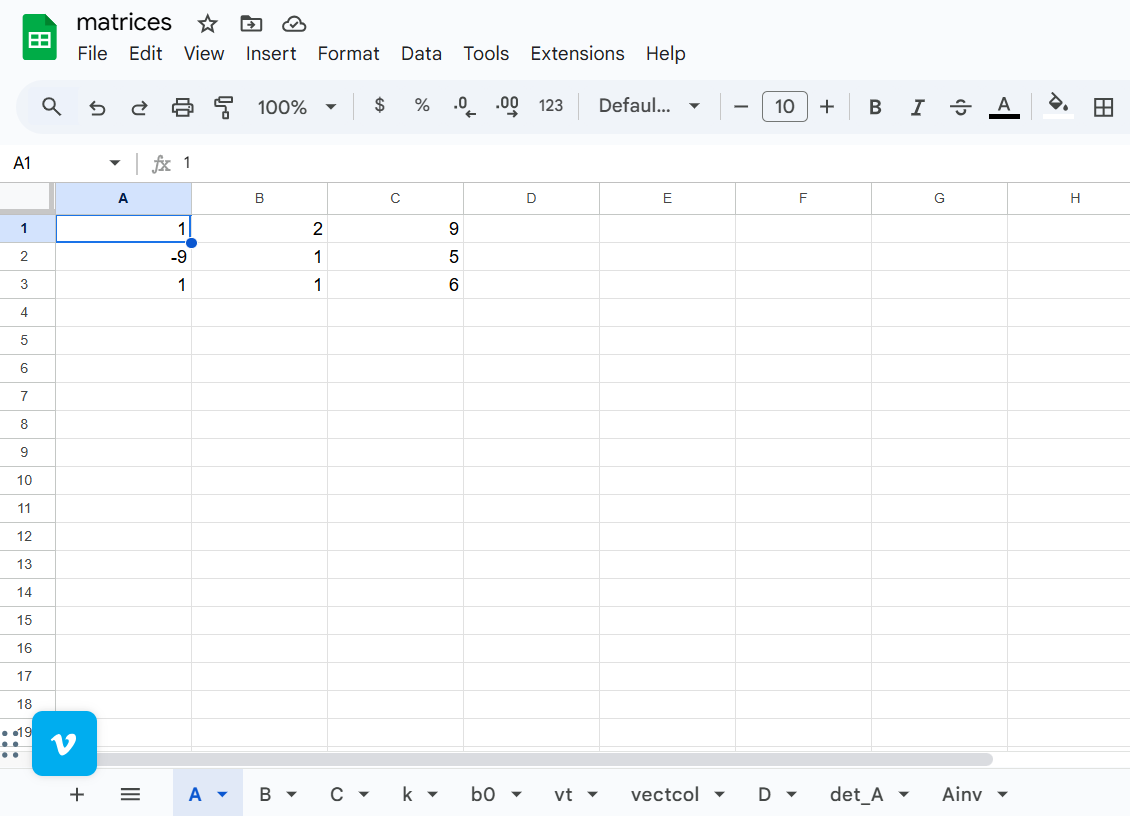

## **2. Configuración y uso de librería de algebra lineal con Google Sheets**

In [10]:
# Importar
from algebra_lineal import *  # traer librerías
version()  # versión de librerías
import numpy as np
import matplotlib.pyplot as plt

📦 ALGEBRA LINEAL v1.4.0
👨‍🏫 Autor: Francisco Pérez Mogollón
📚 Álgebra lineal simplificada con Google Sheets y Excel
🔗 PyPI: https://pypi.org/project/algebra-lineal-sheets/
🛠️  Instalación: pip install algebra-lineal-sheets
🛠️  Con Google Sheets: pip install "algebra-lineal-sheets[google]"


Para logearse y configurar Google Sheets (una vez por sesión). Al poner `configurar()` se debe dar clic en `Permitir`, luego dar clic en nuestra cuenta de gmail, finalmente dar clic en `Continue`y `Continue`.

### 📌 Dos formas de trabajar: Colab + Google Sheets o local + Excel

Desde la **versión 1.1.0** la librería funciona de dos maneras:

| Modo | Dónde | Configuración |
|---|---|---|
| **Google Sheets** (como en la clase) | Google Colab | `configurar()` — busca el Sheet llamado `matrices` |
| **Excel local** (nuevo) | Tu PC (VS Code / Jupyter) | `configurar(sheet='matrices_ejemplo.xlsx')` — usa el Excel de ejemplo del repositorio, **sin internet ni cuenta de Google** |

El archivo [`matrices_ejemplo.xlsx`](https://raw.githubusercontent.com/franperezec/propedeutico-flacso/main/clases/matrices/matrices_ejemplo.xlsx) contiene las mismas matrices de la clase (`A`, `B`, `v1`, `v2`, `b0`), una por pestaña. Debe estar en la misma carpeta que este notebook (si clonaste el repositorio, ya está).

> ⚠️ Las instrucciones y capturas de autenticación de Google que siguen aplican **solo al modo Colab + Google Sheets**. En modo Excel local no se pide ningún permiso.

In [11]:
# Si el Excel no está junto al notebook (p. ej. en Colab), lo descargamos
# del repositorio del curso
import os
if not os.path.exists('matrices_ejemplo.xlsx'):
    from urllib.request import urlretrieve
    urlretrieve('https://raw.githubusercontent.com/franperezec/'
                'propedeutico-flacso/main/clases/matrices/matrices_ejemplo.xlsx',
                'matrices_ejemplo.xlsx')
    print('📥 matrices_ejemplo.xlsx descargado')

# MODO EXCEL LOCAL (nuevo en v1.1.0): usa el archivo de ejemplo del repositorio
configurar(sheet='matrices_ejemplo.xlsx')

# MODO GOOGLE SHEETS (como en la clase de Colab):
#configurar()                     # busca el Sheet llamado 'matrices'
#configurar(sheet='prope2026')    # o un Sheet con otro nombre

📊 Modo Excel local: matrices_ejemplo.xlsx
✅ Archivo encontrado — no se necesita cuenta de Google
📖 Usa ayuda() para ver todos los comandos disponibles


True

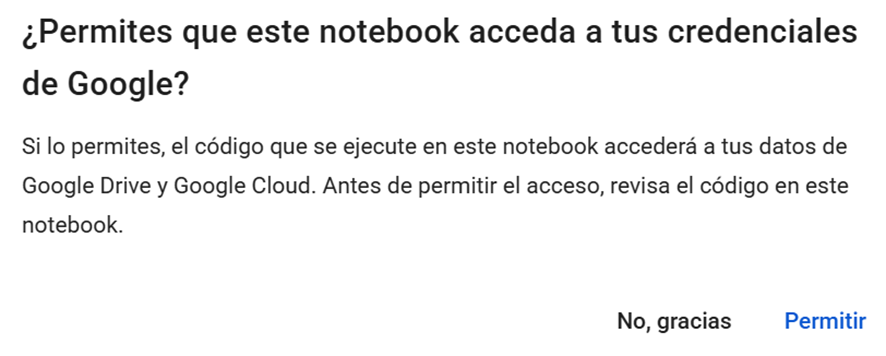

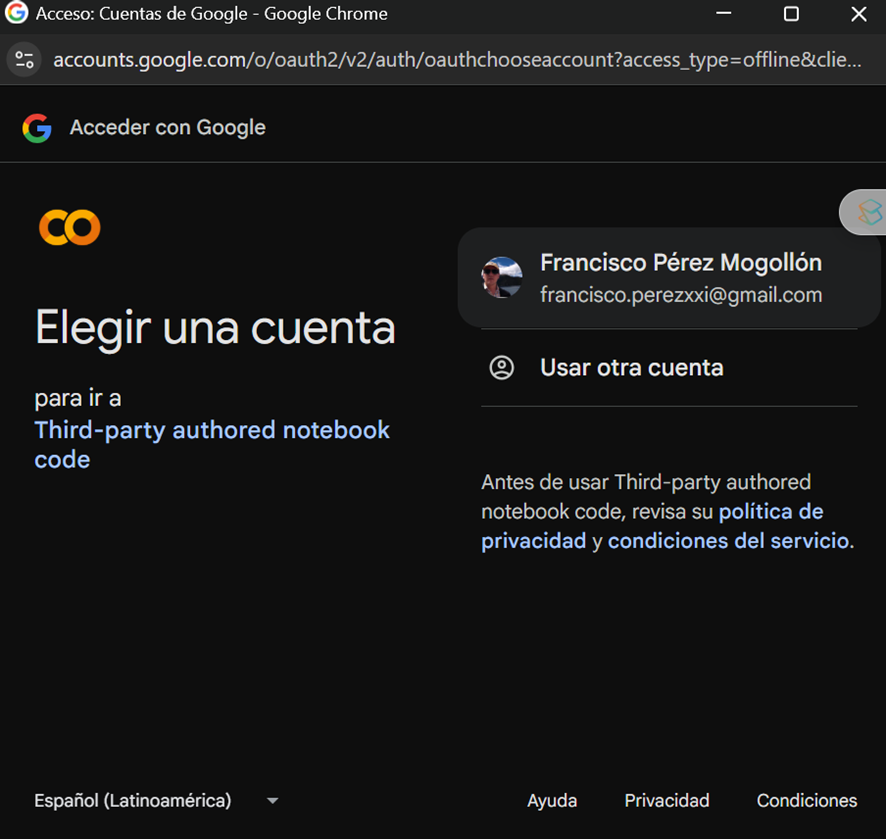

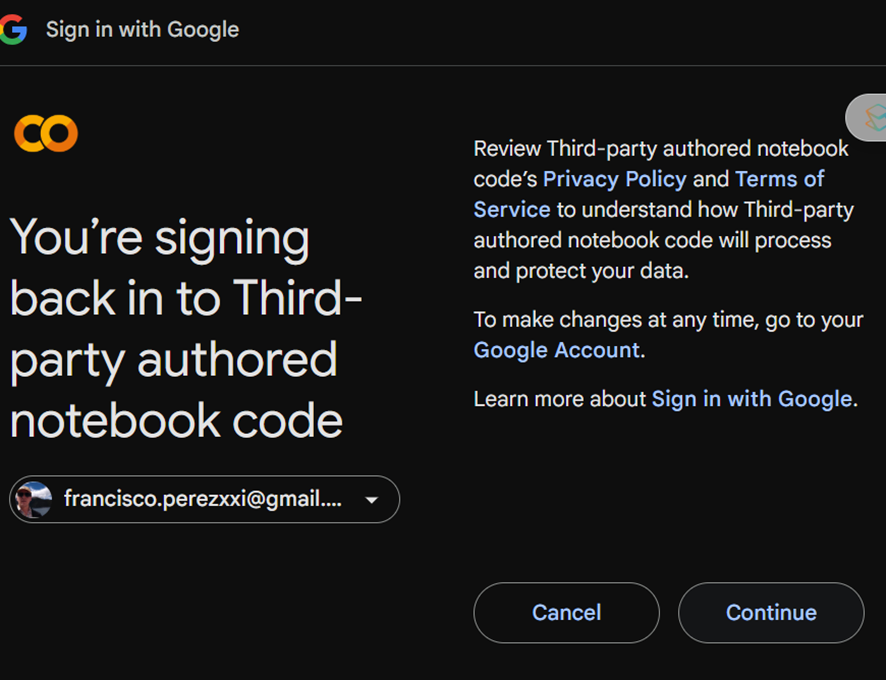

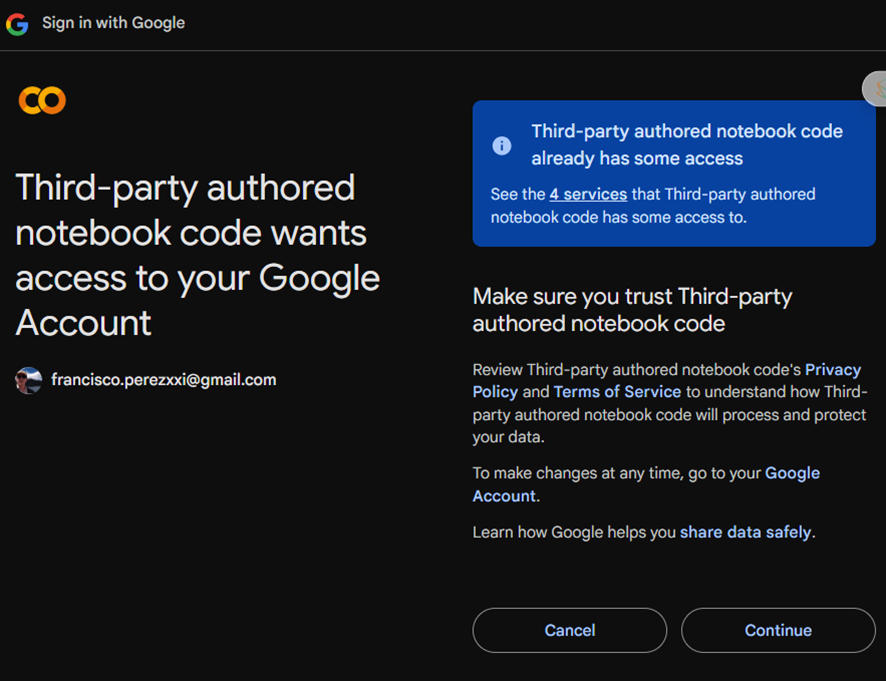

In [12]:
# ver las matrices que tienes disponibles
#workspace('nombrearchivo') si se llama diferente de 'matrices'
workspace()
#workspace()

🏢 WORKSPACE — 📊 Excel local: matrices_ejemplo.xlsx
#   NOMBRE               DIMENSIONES  TIPO           
---------------------------------------------------------------------------


1   A                    3×3          📋 Matriz       
2   B                    3×3          📋 Matriz       
3   v1                   3×1          📉 Vector columna
4   v2                   3×1          📉 Vector columna
5   b0                   3×1          📉 Vector columna
💡 Usa importar('nombre') para traer matrices específicas


{'A': {'tipo': 'matriz', 'dimensiones': (3, 3)},
 'B': {'tipo': 'matriz', 'dimensiones': (3, 3)},
 'v1': {'tipo': 'vector_columna', 'dimensiones': (3, 1)},
 'v2': {'tipo': 'vector_columna', 'dimensiones': (3, 1)},
 'b0': {'tipo': 'vector_columna', 'dimensiones': (3, 1)}}

In [13]:
# cambiar_sheet() cambia la fuente activa en cualquier momento,
# a otro Google Sheet o a otro archivo Excel:
#cambiar_sheet('prope2026')
#cambiar_sheet('otras_matrices.xlsx')

In [14]:
importar()

🔄 Importando TODAS las matrices — 📊 Excel local: matrices_ejemplo.xlsx
✅ A → matriz (3, 3)
✅ B → matriz (3, 3)
✅ v1 → vector columna (3, 1)
✅ v2 → vector columna (3, 1)
✅ b0 → vector columna (3, 1)

🎯 Variables creadas: A, B, v1, v2, b0


{'A': array([[1., 2., 4.],
        [4., 5., 6.],
        [3., 3., 3.]]),
 'B': array([[3., 4., 6.],
        [1., 1., 2.],
        [4., 5., 6.]]),
 'v1': array([[ 1.],
        [ 4.],
        [-6.]]),
 'v2': array([[9.],
        [8.],
        [1.]]),
 'b0': array([[1.],
        [7.],
        [9.]])}

In [15]:
########### importar matrices
#importar()  #importa todas
#importar("A", "B") #importa solo una o varias seleccionadas
importar("A","B","v1","v2")

🔄 Importando desde 📊 Excel local: matrices_ejemplo.xlsx: A, B, v1, v2
✅ A → matriz (3, 3)
✅ B → matriz (3, 3)
✅ v1 → vector columna (3, 1)
✅ v2 → vector columna (3, 1)

🎯 ¡Listo! Variables disponibles: A, B, v1, v2


{'A': array([[1., 2., 4.],
        [4., 5., 6.],
        [3., 3., 3.]]),
 'B': array([[3., 4., 6.],
        [1., 1., 2.],
        [4., 5., 6.]]),
 'v1': array([[ 1.],
        [ 4.],
        [-6.]]),
 'v2': array([[9.],
        [8.],
        [1.]])}

In [16]:
########### exportar matrices
#exportar() #exportar todas las matrices creadas a Google Sheets
#exportar("D","Ainv") #exportar una o varias de las matrices creadas

En resumen:

*   `configurar()` permite conectar con Google Sheets
*   `workspace()` ver matrices disponibles en el archivo `matrices`
*   `importar()` cargar en Google Colab las matrices seleccionadas
*   `exportar()` cargar en Google Sheets las matrices creadas

Con esto ya nos podemos concentrar en trabajar en álgebra lineal con `Numpy`. Para más detalle podemos consultar con `ayuda()`.



In [17]:
ayuda()

📚 ALGEBRA LINEAL - GUÍA COMPLETA
📦 Instalación:
   pip install algebra-lineal-sheets
   pip install "algebra-lineal-sheets[google]"   # con Google Sheets

🔧 CONFIGURACIÓN:
   configurar()                 # Configurar una vez al inicio
   configurar(sheet='prope2026')             # Google Sheet por nombre
   configurar(sheet='https://docs.goo...')   # Google Sheet por enlace
   configurar(sheet='C:/datos/notas.xlsx')   # Excel local (sin Google)
   configurar(sheet='datos/')                # Carpeta CSV (un .csv por matriz)
   cambiar_sheet('fuente')      # Cambiar de archivo en cualquier momento

🏢 VER CONTENIDO:
   workspace()                  # Ver matrices en la fuente activa

📥 IMPORTAR:
   importar()                   # Importar todas las matrices
   importar('A')                # Importar solo A
   importar('A', 'B', 'v')      # Importar A, B y v
   importar('A', sheet_name='otro_archivo')  # Desde otra fuente

🧮 OPERACIONES (después de importar):
   C = A @ B                    

## **3. Operaciones matriciales**

In [18]:
#importar matrices A y B
importar("A","B")

🔄 Importando desde 📊 Excel local: matrices_ejemplo.xlsx: A, B
✅ A → matriz (3, 3)
✅ B → matriz (3, 3)

🎯 ¡Listo! Variables disponibles: A, B


{'A': array([[1., 2., 4.],
        [4., 5., 6.],
        [3., 3., 3.]]),
 'B': array([[3., 4., 6.],
        [1., 1., 2.],
        [4., 5., 6.]])}

### **3.1 Operaciones Aritméticas Básicas (elemento por elemento)**

In [19]:
# --- Operaciones Aritméticas Básicas (elemento por elemento) ---

# Sumar las dos matrices. Cada elemento de 'A' se suma con el de 'B' en la misma posición.
suma = A + B
# Alternativa: suma = np.add(A, B)
print(f"Suma de A + B:\n{suma}\n")

# Restar la matriz 'B' de la matriz 'A'.
resta = A - B
# Alternativa: resta = np.subtract(A, B)
print(f"Resta de A - B:\n{resta}\n")

# Multiplicar las matrices elemento por elemento (NO es la multiplicación de matrices).
multiplicacion_elemento = A * B
# Alternativa: multiplicacion_elemento = np.multiply(A, B)
print(f"Multiplicación elemento por elemento (A * B):\n{multiplicacion_elemento}\n")

# Dividir las matrices elemento por elemento.
division_elemento = A / B
# Alternativa: division_elemento = np.divide(A, B)
print(f"División elemento por elemento (A / B):\n{division_elemento}\n")


# --- Otras operaciones comunes ---

# Calcular la raíz cuadrada de cada elemento en la matriz 'A'.
print(f"Raíz cuadrada de la matriz a:\n{np.sqrt(A)}\n")

# Calcular el exponente de cada elemento en la matriz 'B'.
print(f"Exponencial de la matriz b:\n{np.exp(B)}\n")



Suma de A + B:
[[ 4.  6. 10.]
 [ 5.  6.  8.]
 [ 7.  8.  9.]]

Resta de A - B:
[[-2. -2. -2.]
 [ 3.  4.  4.]
 [-1. -2. -3.]]

Multiplicación elemento por elemento (A * B):
[[ 3.  8. 24.]
 [ 4.  5. 12.]
 [12. 15. 18.]]

División elemento por elemento (A / B):
[[0.33333333 0.5        0.66666667]
 [4.         5.         3.        ]
 [0.75       0.6        0.5       ]]

Raíz cuadrada de la matriz a:
[[1.         1.41421356 2.        ]
 [2.         2.23606798 2.44948974]
 [1.73205081 1.73205081 1.73205081]]

Exponencial de la matriz b:
[[ 20.08553692  54.59815003 403.42879349]
 [  2.71828183   2.71828183   7.3890561 ]
 [ 54.59815003 148.4131591  403.42879349]]



### **3.2 Multiplicación de matrices**

In [20]:
# --- Multiplicación de Matrices (Producto Escalar) ---

# Realizar el producto escalar (o producto punto) de 'A' y 'B'.
# Se usa el operador @ o la función np.dot().
producto_escalar = A @ B
# Alternativa: producto_escalar = np.dot(A, B)
print(f"Producto escalar de matrices (A @ B):\n{producto_escalar}\n")

Producto escalar de matrices (A @ B):
[[21. 26. 34.]
 [41. 51. 70.]
 [24. 30. 42.]]



### **3.3 Broadcasting: operar entre arrays de distinta forma**

In [21]:
# --- Broadcasting ---
# El broadcasting permite a NumPy realizar operaciones en arrays de diferentes formas.

# Ejemplo 1: Sumar un escalar (un solo número) a una matriz.
# El escalar '5' se "expande" para sumarse a cada elemento de 'A'.
matriz_mas_escalar = A + 5
print(f"Suma de una matriz y un escalar (Broadcasting):\n{matriz_mas_escalar}\n")

# Ejemplo 2: Sumar un vector a una matriz.
# Crear un vector 'v'
v3 = np.array([10, 20, 30])
print(f"Vector v: {v3}\n")

# El vector 'v' se "expande" para sumarse a cada fila de la matriz 'A'.
matriz_mas_vector = A + v3
print(f"Suma de una matriz y un vector (Broadcasting):\n{matriz_mas_vector}\n")

Suma de una matriz y un escalar (Broadcasting):
[[ 6.  7.  9.]
 [ 9. 10. 11.]
 [ 8.  8.  8.]]

Vector v: [10 20 30]

Suma de una matriz y un vector (Broadcasting):
[[11. 22. 34.]
 [14. 25. 36.]
 [13. 23. 33.]]



In [22]:
#Un ejemplo aplicado a la economía:

P = np.array([100, 200, 300]) # precios
inflacion = 1.05              # 5% de inflación
P_nuevo = P * inflacion
print("Precios ajustados por inflación:", P_nuevo)

Precios ajustados por inflación: [105. 210. 315.]


### **3.4 Transpuesta, Traza, Determinante e Inversa de una matriz**

In [23]:
importar("A")
# --- 1. Transpuesta de una Matriz ---
# La forma más común y corta es usar el atributo .T
transpuesta_A = A.T
print(f"Transpuesta de A (usando A.T):\n{transpuesta_A}\n")

# También se puede usar la función np.transpose(), que es útil si
# prefieres un estilo de programación más funcional.
# transpuesta_A_func = np.transpose(A)
# print(f"Transpuesta de A (usando np.transpose()):\n{transpuesta_A_func}\n")


# --- 2. Traza de una Matriz ---
# Se usa la función np.trace() para sumar los elementos de la diagonal.
traza_A = np.trace(A)
print(f"Traza de A (usando np.trace()): {traza_A}\n")


# --- 3. Determinante de una Matriz ---
# Se usa la función np.linalg.det() del módulo de álgebra lineal de NumPy.
determinante_A = np.linalg.det(A)
print(f"Determinante de A (usando np.linalg.det()): {determinante_A:.2f}\n")


# --- 4. Inversa de una Matriz ---
# Se usa la función np.linalg.inv() del módulo de álgebra lineal.
# La matriz debe tener un determinante diferente de cero.

inversa_A = np.linalg.inv(A)
print(f"Inversa de A (usando np.linalg.inv()):\n{inversa_A}\n")

🔄 Importando desde 📊 Excel local: matrices_ejemplo.xlsx: A
✅ A → matriz (3, 3)

🎯 ¡Listo! Variables disponibles: A
Transpuesta de A (usando A.T):
[[1. 4. 3.]
 [2. 5. 3.]
 [4. 6. 3.]]

Traza de A (usando np.trace()): 9.0

Determinante de A (usando np.linalg.det()): -3.00

Inversa de A (usando np.linalg.inv()):
[[ 1.         -2.          2.66666667]
 [-2.          3.         -3.33333333]
 [ 1.         -1.          1.        ]]



In [24]:
inversa_A @ A

array([[ 1.00000000e+00, -1.77635684e-15, -1.77635684e-15],
       [ 8.88178420e-16,  1.00000000e+00,  8.88178420e-16],
       [ 0.00000000e+00,  0.00000000e+00,  1.00000000e+00]])

In [25]:
# --- 4. Inversa de una Matriz (usando una función) ---
# Se puede encapsular la lógica en una función para reutilizarla fácilmente.

def calcular_y_verificar_inversa(matrix):
    """
    Calcula la inversa de una matriz, la imprime y verifica el resultado.
    Crea una matriz identidad del tamaño correcto dinámicamente.
    """
    print("--- Calculando inversa con la función ---")
    # Se calcula el determinante dentro de la función.
    determinante = np.linalg.det(matrix)

    if determinante != 0:
        # Se calcula la inversa.
        inversa = np.linalg.inv(matrix)
        print(f"Inversa de la matriz:\n{inversa}\n")

        # Verificación: El producto de una matriz por su inversa da la matriz identidad.
        # Para crear una identidad del tamaño de 'matrix', usamos matrix.shape[0].
        # matrix.shape devuelve (filas, columnas), y .shape[0] nos da el número de filas.
        num_filas = matrix.shape[0]
        identidad = np.eye(num_filas)

        producto = matrix @ inversa

        print(f"Verificación (Matriz @ Inversa), debe dar la identidad de {num_filas}x{num_filas}:")
        # Se redondean los valores para evitar imprecisiones de punto flotante.
        print(np.round(producto))
    else:
        print("La matriz no tiene inversa (su determinante es 0).")

# Llamar a la función con nuestra matriz A.
calcular_y_verificar_inversa(A)


--- Calculando inversa con la función ---
Inversa de la matriz:
[[ 1.         -2.          2.66666667]
 [-2.          3.         -3.33333333]
 [ 1.         -1.          1.        ]]

Verificación (Matriz @ Inversa), debe dar la identidad de 3x3:
[[ 1.  0.  0.]
 [ 0.  1. -0.]
 [ 0.  0.  1.]]


### **3.5 Resolución de sistemas de ecuaciones lineales**

In [26]:
importar("A","b0")
# Resolver el sistema Ax = b
x_sol = np.linalg.solve(A, b0)
print("Solución del sistema:", x_sol)

# Determinante y matriz inversa
#print("Determinante de A:", np.linalg.det(A))
#print("Inversa de A:\n", np.linalg.inv(A))

🔄 Importando desde 📊 Excel local: matrices_ejemplo.xlsx: A, b0
✅ A → matriz (3, 3)
✅ b0 → vector columna (3, 1)

🎯 ¡Listo! Variables disponibles: A, b0
Solución del sistema: [[ 11.]
 [-11.]
 [  3.]]


In [27]:
# Verificación directa
b_calc = A @ x_sol
print("b calculado:", b_calc)
print("b original:", b0)

# Comprobación con tolerancia numérica
es_correcto = np.allclose(b_calc, b0)
print("¿La solución es correcta?:", es_correcto)


b calculado: [[1.]
 [7.]
 [9.]]
b original: [[1.]
 [7.]
 [9.]]
¿La solución es correcta?: True


**3.6 Valores y vectores propios, Diagonalización**

In [28]:
importar("B")

# Configurar las opciones de impresión de NumPy para mejor legibilidad
# precision=4: muestra 4 decimales
# suppress=True: evita la notación científica para números pequeños
np.set_printoptions(precision=4, suppress=True)



🔄 Importando desde 📊 Excel local: matrices_ejemplo.xlsx: B
✅ B → matriz (3, 3)

🎯 ¡Listo! Variables disponibles: B


In [29]:
# NOTA: usamos np.linalg.eig(), que funciona para cualquier matriz cuadrada.
# np.linalg.eigh() es solo para matrices SIMETRICAS (mas rapido y estable,
# y garantiza valores propios reales); aplicado a una matriz NO simetrica
# como esta B daria resultados incorrectos.
print("--- 1. Valores y Vectores Propios ---")
print(f"Matriz B:\n{B}\n")

vals_s, vecs_s = np.linalg.eig(B)
print(f"Valores propios (con eig):\n{vals_s}")
print(f"Vectores propios (con eig) como columnas:\n{vecs_s}\n")

--- 1. Valores y Vectores Propios ---
Matriz B:
[[3. 4. 6.]
 [1. 1. 2.]
 [4. 5. 6.]]

Valores propios (con eig):
[11.0151+0.j -0.2318+0.j -0.7833+0.j]
Vectores propios (con eig) como columnas:
[[-0.651 +0.j -0.7956+0.j -0.6493+0.j]
 [-0.2106+0.j  0.6054+0.j -0.3768+0.j]
 [-0.7292+0.j  0.0249+0.j  0.6606+0.j]]



In [30]:
# ------------------------------------
# 2. Diagonalización (A = V * D * V^-1)
# ------------------------------------
def intentar_diagonalizar(M):
    """
    Intenta diagonalizar una matriz M y muestra el proceso.
    Devuelve si fue posible y los componentes de la diagonalización.
    """
    print("Matriz original M:\n", M)

    # Cálculo de valores y vectores propios
    vals, V = np.linalg.eig(M)
    print("\nMatriz de vectores propios V:\n", V)
    print("\nValores propios (vector λ):\n", vals)

    # Comprobamos si la matriz de vectores propios es invertible
    detV = np.linalg.det(V)
    print("\nDeterminante de V:", detV)

    if abs(detV) < 1e-8:
        print("\n❌ La matriz de vectores propios no es invertible (det ≈ 0). No se puede diagonalizar.\n")
        return False, vals, V, None, None, None

    # Construimos matriz diagonal D
    D = np.diag(vals)
    print("\nMatriz diagonal D:\n", D)

    # Calculamos la inversa de V
    V_inv = np.linalg.inv(V)
    print("\nMatriz inversa de V:\n", V_inv)

    # Reconstrucción de M
    reconstruida = V @ D @ V_inv
    print("\nMatriz reconstruida (V D V^-1):\n", reconstruida)

    # Verificación
    es_correcta = np.allclose(M, reconstruida)
    print("\n✅ ¿M == V D V^-1?:", es_correcta, "\n")

    return es_correcta, vals, V, D, V_inv, reconstruida


In [31]:
# Ejemplo
print("--- 2. Diagonalización ---")
es_diag_B, valsB, VB, DB, VB_inv, B_rec = intentar_diagonalizar(B)
print(f"¿La matriz B es diagonalizable?: {es_diag_B}")

--- 2. Diagonalización ---
Matriz original M:
 [[3. 4. 6.]
 [1. 1. 2.]
 [4. 5. 6.]]

Matriz de vectores propios V:
 [[-0.651 +0.j -0.7956+0.j -0.6493+0.j]
 [-0.2106+0.j  0.6054+0.j -0.3768+0.j]
 [-0.7292+0.j  0.0249+0.j  0.6606+0.j]]

Valores propios (vector λ):
 [11.0151+0.j -0.2318+0.j -0.7833+0.j]

Determinante de V: 

(-0.8790043152718814+0j)



Matriz diagonal D:
 [[11.0151+0.j  0.    +0.j  0.    +0.j]
 [ 0.    +0.j -0.2318+0.j  0.    +0.j]
 [ 0.    +0.j  0.    +0.j -0.7833+0.j]]

Matriz inversa de V:
 [[-0.4657-0.j -0.5795-0.j -0.7882-0.j]
 [-0.4709-0.j  1.028 +0.j  0.1235+0.j]
 [-0.4963-0.j -0.6785-0.j  0.639 +0.j]]

Matriz reconstruida (V D V^-1):
 [[3.+0.j 4.+0.j 6.+0.j]
 [1.+0.j 1.+0.j 2.+0.j]
 [4.+0.j 5.+0.j 6.+0.j]]

✅ ¿M == V D V^-1?: True 

¿La matriz B es diagonalizable?: True


### **3.7 Operaciones con vectores**

In [32]:
# Configurar las opciones de impresión de NumPy para una salida más limpia.
np.set_printoptions(precision=4, suppress=True)

# --- 1. Definición de Vectores ---
# Creamos dos vectores de ejemplo en un espacio de 3 dimensiones.
importar("v1","v2")

🔄 Importando desde 📊 Excel local: matrices_ejemplo.xlsx: v1, v2
✅ v1 → vector columna (3, 1)
✅ v2 → vector columna (3, 1)

🎯 ¡Listo! Variables disponibles: v1, v2


{'v1': array([[ 1.],
        [ 4.],
        [-6.]]),
 'v2': array([[9.],
        [8.],
        [1.]])}

--- Vectores Iniciales ---
Vector v1: [ 1.  4. -6.]
Vector v2: [9. 8. 1.]

--- Norma (Magnitud) ---
La longitud del vector v1 es: 7.2801
La longitud del vector v2 es: 12.0830

--- Distancia ---
La distancia entre v1 y v2 es: 11.3578

--- Producto Punto ---
El producto punto de v1 y v2 es: 35.0000

--- Ángulo ---
El ángulo entre v1 y v2 es: 66.5542 grados

--- Vectores Normalizados (Unitarios) ---
Vector v1 normalizado: [ 0.1374  0.5494 -0.8242]
Vector v2 normalizado: [0.7448 0.6621 0.0828]

Verificación - Norma de v1 normalizado: 1.0
--- Visualización ---


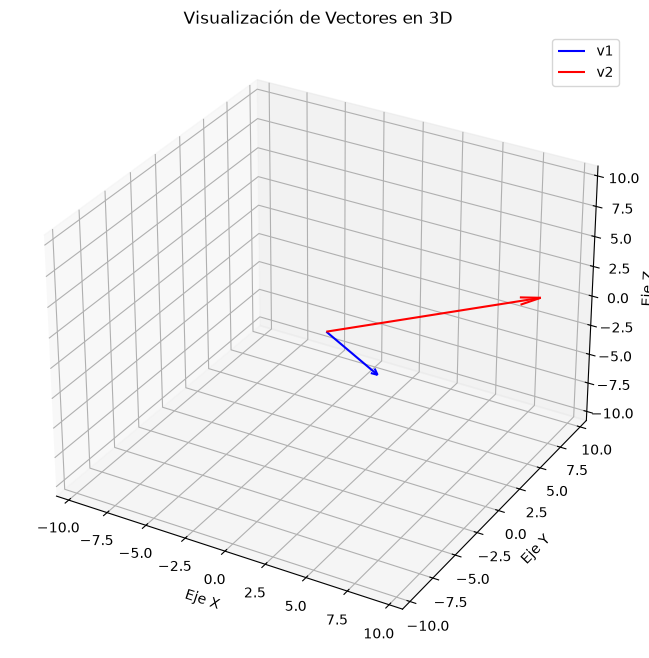

In [33]:
# --- 1. Definición de los Vectores ---
# --- 1.1 Asegurar que los vectores son 1D para los cálculos ---
print("--- Vectores Iniciales ---")
v1 = v1.flatten()
v2 = v2.flatten()
print(f"Vector v1: {v1}")
print(f"Vector v2: {v2}\n")

# --- 2. Norma o Magnitud de un Vector ---
# La norma es la "longitud" del vector. Un valor alto significa un vector largo.
norma_v1 = np.linalg.norm(v1)
norma_v2 = np.linalg.norm(v2)

print("--- Norma (Magnitud) ---")
print(f"La longitud del vector v1 es: {norma_v1:.4f}")
print(f"La longitud del vector v2 es: {norma_v2:.4f}\n")


# --- 3. Distancia entre dos Vectores ---
# La distancia euclidiana es la longitud del vector que resulta de restar v1 y v2.
# Un valor bajo significa que las puntas de los vectores están muy cercanas.
distancia = np.linalg.norm(v1 - v2)

print("--- Distancia ---")
print(f"La distancia entre v1 y v2 es: {distancia:.4f}\n")


# --- 4. Producto Punto (Dot Product) ---
# El producto punto indica la alineación de los vectores.
# > 0: apuntan en una dirección similar. < 0: opuesta. = 0: son ortogonales.
producto_punto = np.dot(v1, v2)

print("--- Producto Punto ---")
print(f"El producto punto de v1 y v2 es: {producto_punto:.4f}\n")


# --- 5. Ángulo entre dos Vectores ---
# El ángulo mide la separación entre vectores.
# 0°: paralelos. 90°: ortogonales. 180°: opuestos.
cos_angulo = producto_punto / (norma_v1 * norma_v2)
angulo_en_grados = np.degrees(np.arccos(cos_angulo))

print("--- Ángulo ---")
print(f"El ángulo entre v1 y v2 es: {angulo_en_grados:.4f} grados\n")


# --- 6. Normalización (Vectores Unitarios) ---
# Un vector normalizado (unitario) mantiene la dirección pero con longitud 1.
# Es útil para comparar solo la dirección de los vectores, ignorando su magnitud.
v1_normalizado = v1 / norma_v1
v2_normalizado = v2 / norma_v2

print("--- Vectores Normalizados (Unitarios) ---")
print(f"Vector v1 normalizado: {v1_normalizado}")
print(f"Vector v2 normalizado: {v2_normalizado}\n")

# Verificación opcional: la norma de un vector unitario siempre es 1.
print(f"Verificación - Norma de v1 normalizado: {np.linalg.norm(v1_normalizado):.1f}")

# --- 7. Visualización Básica ---
# Esta sección grafica los vectores si son de 2 o 3 dimensiones.
dimension = len(v1)
print("--- Visualización ---")

if dimension == 2:
    # Crea una figura y ejes para el gráfico 2D.
    fig, ax = plt.subplots(figsize=(6, 6))
    # Dibuja los vectores como flechas desde el origen.
    ax.quiver(0, 0, v1[0], v1[1], angles='xy', scale_units='xy', scale=1, color='blue', label='v1')
    ax.quiver(0, 0, v2[0], v2[1], angles='xy', scale_units='xy', scale=1, color='red', label='v2')
    # Configura el gráfico para que se vea bien.
    max_val = np.max(np.abs(np.concatenate((v1, v2)))) * 1.2
    ax.set_xlim([-max_val, max_val])
    ax.set_ylim([-max_val, max_val])
    ax.set_xlabel('Eje X')
    ax.set_ylabel('Eje Y')
    ax.set_title('Visualización de Vectores en 2D')
    ax.grid(True)
    ax.set_aspect('equal', adjustable='box')
    ax.legend()
    plt.show()

elif dimension == 3:
    # Crea una figura y ejes para el gráfico 3D.
    fig = plt.figure(figsize=(8, 8))
    ax = fig.add_subplot(111, projection='3d')
    # Dibuja los vectores como flechas desde el origen.
    ax.quiver(0, 0, 0, v1[0], v1[1], v1[2], color='blue', label='v1', arrow_length_ratio=0.1)
    ax.quiver(0, 0, 0, v2[0], v2[1], v2[2], color='red', label='v2', arrow_length_ratio=0.1)
    # Configura el gráfico para que se vea bien.
    max_val = np.max(np.abs(np.concatenate((v1, v2)))) * 1.2
    ax.set_xlim([-max_val, max_val])
    ax.set_ylim([-max_val, max_val])
    ax.set_zlim([-max_val, max_val])
    ax.set_xlabel('Eje X')
    ax.set_ylabel('Eje Y')
    ax.set_zlabel('Eje Z')
    ax.set_title('Visualización de Vectores en 3D')
    ax.legend()
    plt.show()

else:
    # Mensaje si los vectores no son 2D o 3D.
    print(f"La visualización no está disponible para vectores de {dimension} dimensiones.")

In [34]:
# Exportamos la solucion del sistema a un archivo NUEVO
# (asi no modificamos matrices_ejemplo.xlsx, que es el material de ejemplo)
exportar('x_sol', sheet_name='resultados.xlsx')

# Otras formas de exportar:
#exportar()             # exporta TODAS las variables exportables a la fuente activa
#exportar('D', 'Ainv')  # solo variables especificas

✅ x_sol → creada


🎯 ¡Exportadas exitosamente!: x_sol
🔗 Revisa tu archivo — 📊 Excel local: resultados.xlsx


['x_sol']